In [ ]:
model.eval()
with torch.no_grad():
  correct=0
  total=0
  for x,length,y in test_loader:
    x=x.to(device)
    y=y.to(device)
    output = model(x,length)
    prediction = torch.argmax(output,1)
    correct+=(y==prediction).sum().item()
    total+=y.size(0)
  print("Test accuracy:",correct*100/total)

Test accuracy: 69.88399492477797


In [ ]:
y_true = []
y_pred = []

with torch.no_grad():

    for x, lengths, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        output = model(x, lengths)

        pred = output.argmax(1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Player1","Player2"]
))

              precision    recall  f1-score   support

     Player1       0.71      0.70      0.70     11395
     Player2       0.68      0.70      0.69     10673

    accuracy                           0.70     22068
   macro avg       0.70      0.70      0.70     22068
weighted avg       0.70      0.70      0.70     22068



Text(0, 0.5, 'loss')

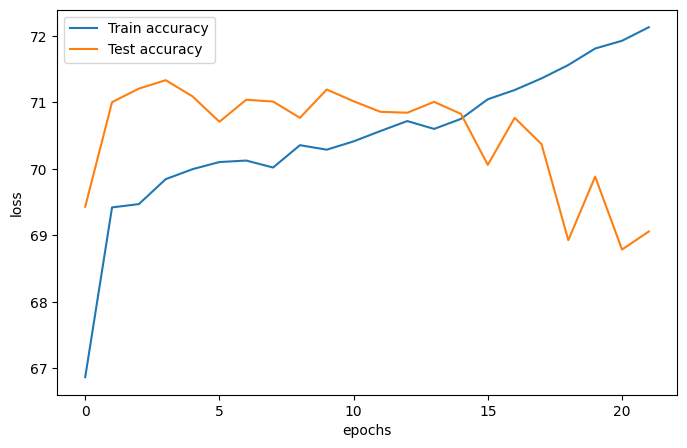

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label = "Train accuracy")
plt.plot(val_accuracies, label = "Test accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel('loss')

Text(0, 0.5, 'loss')

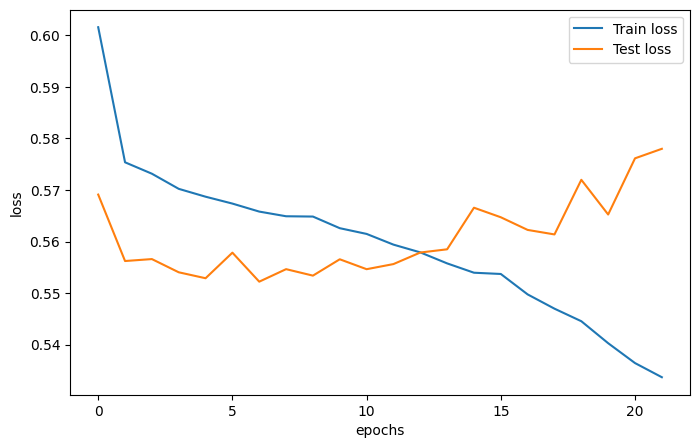

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label = "Train loss")
plt.plot(val_losses, label = "Test loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel('loss')

We observe that test accuracy goes down only a little before climbing back up but the test loss continues to increase, it seems likely that the model may overfit so let's see by training for longer.

In [ ]:
additional_epochs=20
for epoch in range(num_epochs, num_epochs+additional_epochs):



    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, lengths, y in train_loader:
        x=x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x, lengths.cpu())

        loss = loss_fn(output, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()

        pred = output.argmax(dim=1)

        total += y.size(0)
        correct += (pred == y).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)



    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x, lengths, y in test_loader:

            x = x.to(device)
            y = y.to(device)

            output = model(x, lengths.cpu())

            loss = loss_fn(output, y)

            val_running_loss += loss.item()

            pred = output.argmax(dim=1)

            val_total += y.size(0)
            val_correct += (pred == y).sum().item()

    val_loss = val_running_loss / len(test_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    ##########################
    # RESULTS
    ##########################

    print(
        f"Epoch [{epoch+1}/{num_epochs+additional_epochs}] | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch [21/40] | Train Loss: 0.5279 | Train Acc: 72.67% | Val Loss: 0.5812 | Val Acc: 69.64%
Epoch [22/40] | Train Loss: 0.5236 | Train Acc: 72.96% | Val Loss: 0.5869 | Val Acc: 68.41%
Epoch [23/40] | Train Loss: 0.5207 | Train Acc: 73.36% | Val Loss: 0.5890 | Val Acc: 69.45%
Epoch [24/40] | Train Loss: 0.5172 | Train Acc: 73.65% | Val Loss: 0.5925 | Val Acc: 68.84%
Epoch [25/40] | Train Loss: 0.5138 | Train Acc: 73.64% | Val Loss: 0.5900 | Val Acc: 68.01%
Epoch [26/40] | Train Loss: 0.5107 | Train Acc: 73.96% | Val Loss: 0.6024 | Val Acc: 68.26%
Epoch [27/40] | Train Loss: 0.5065 | Train Acc: 74.31% | Val Loss: 0.5961 | Val Acc: 68.69%
Epoch [28/40] | Train Loss: 0.5043 | Train Acc: 74.53% | Val Loss: 0.6120 | Val Acc: 68.73%
Epoch [29/40] | Train Loss: 0.5017 | Train Acc: 74.97% | Val Loss: 0.5968 | Val Acc: 68.15%
Epoch [30/40] | Train Loss: 0.4987 | Train Acc: 74.91% | Val Loss: 0.6266 | Val Acc: 67.69%
Epoch [31/40] | Train Loss: 0.4951 | Train Acc: 75.31% | Val Loss: 0.6133 | Val 

Text(0, 0.5, 'loss')

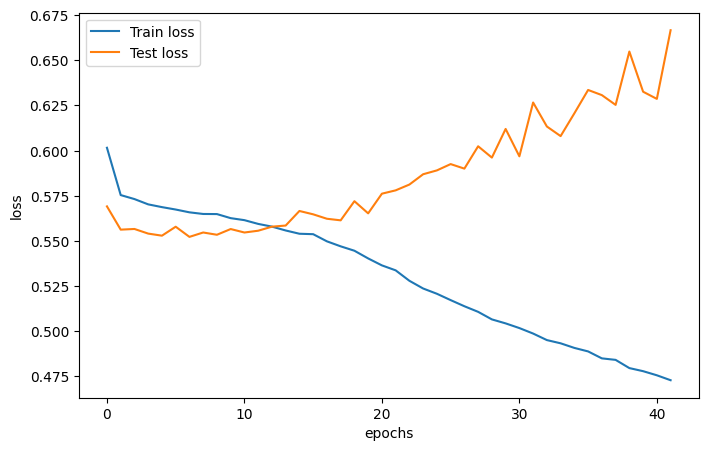

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label = "Train loss")
plt.plot(val_losses, label = "Test loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel('loss')

We can clearly observe that the test loss is constantly increasing and the model is overfitting. In this case, it is ideal that we choose to move with the trained parameters obtained over 20 epochs initially and we are going to keep that itself.


In [ ]:
checkpoint = torch.load(
"best_tennis_lstm.pt",
map_location=device)

model.load_state_dict(
    checkpoint['model_state_dict'])
optimizer.load_state_dict(
    checkpoint['optimizer_state_dict'])

In [ ]:
y_true = []
y_pred = []

with torch.no_grad():

    for x, lengths, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        output = model(x, lengths)

        pred = output.argmax(1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Player1","Player2"]
))

print(f"Optimal Training Accuracy Obtained: {best_val_acc:.2f}%") 

              precision    recall  f1-score   support

     Player1       0.71      0.70      0.70     11395
     Player2       0.68      0.70      0.69     10673

    accuracy                           0.70     22068
   macro avg       0.70      0.70      0.70     22068
weighted avg       0.70      0.70      0.70     22068

Optimal Training Accuracy Obtained: 71.33%


Text(0, 0.5, 'loss')

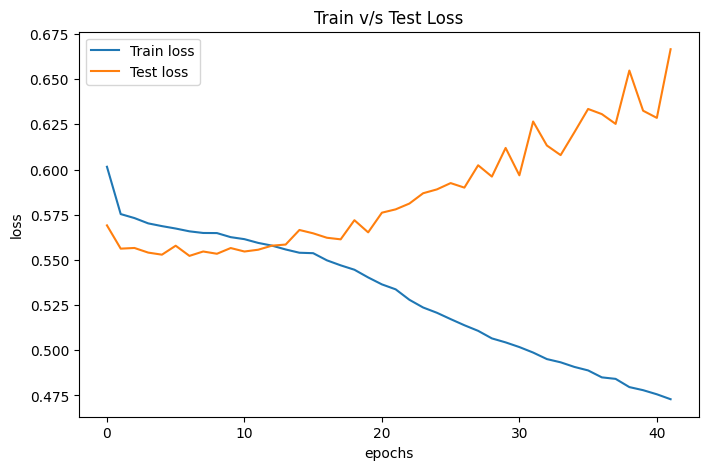

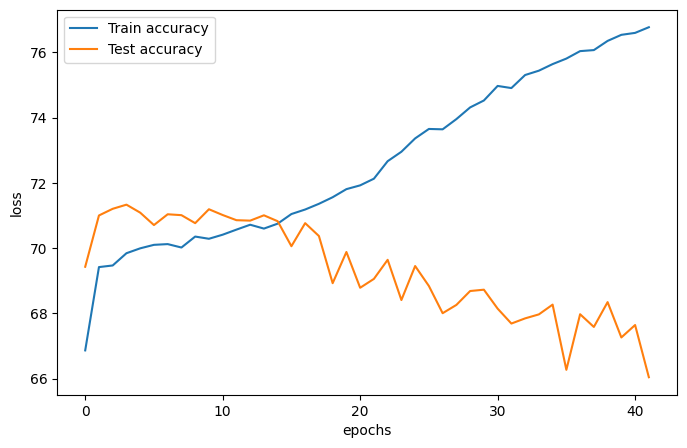

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label = "Train loss")
plt.plot(val_losses, label = "Test loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel('loss')
plt.title('Train v/s Test Loss')

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label = "Train accuracy")
plt.plot(val_accuracies, label = "Test accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel('loss')

In [ ]:
torch.load
model.eval()

predictions = []
targets = []

with torch.no_grad():
    for x, lengths, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        output = model(x, lengths.cpu())

        pred = output.argmax(1)

        predictions.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())

cm = confusion_matrix(targets, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Player 1","Player 2"],
    yticklabels=["Player 1","Player 2"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()